In [1]:
# ============================================
# MDI3003 - Lab 01: House Price Prediction
# Step 1: Environment Setup
# ============================================

# Install required packages
!pip install -q pandas numpy matplotlib seaborn scikit-learn statsmodels joblib

# Import all libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
SEED = 42
np.random.seed(SEED)

# Print versions to verify installation
print("=" * 60)
print("ENVIRONMENT SETUP COMPLETE")
print("=" * 60)
print(f"Python version: 3.x")
print(f"NumPy version: {np.__version__}")
print(f"pandas version: {pd.__version__}")
print(f"scikit-learn version: {sklearn.__version__}")
print(f"Seaborn version: {sns.__version__}")
print("=" * 60)
print(" All libraries imported successfully!")

ENVIRONMENT SETUP COMPLETE
Python version: 3.x
NumPy version: 2.0.2
pandas version: 2.2.2
scikit-learn version: 1.6.1
Seaborn version: 0.13.2
 All libraries imported successfully!


In [2]:
# ============================================
# Step 2: Load California Housing Dataset
# ============================================

from sklearn.datasets import fetch_california_housing


print("LOADING CALIFORNIA HOUSING DATASET")


# Load the dataset
housing = fetch_california_housing(as_frame=True)

# Rename target column for clarity
df = housing.frame.rename(columns={'MedHouseVal': 'Price'})

print(f" Dataset loaded successfully!")
print(f"Shape: {df.shape} (rows, columns)")
print(f"Number of samples: {df.shape[0]}")
print(f"Number of features: {df.shape[1] - 1}")

# Display first 5 rows
print("\n First 5 rows:")
display(df.head())

LOADING CALIFORNIA HOUSING DATASET
 Dataset loaded successfully!
Shape: (20640, 9) (rows, columns)
Number of samples: 20640
Number of features: 8

 First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
# ============================================
# Step 3: Dataset Information & Data Audit
# ============================================


print("DATASET INFORMATION")


# Dataset description
print("\n Dataset Description:")
print(housing.DESCR[:600])
print("...")

# Data types and info
print("\n Data Types:")
print(df.dtypes)

# Quick statistics
print("\n Summary Statistics:")
display(df.describe())

# Data Quality Audit

print("DATA QUALITY AUDIT")


audit = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_n': df.isna().sum(),
    'missing_pct': 100 * df.isna().mean(),
    'unique_n': df.nunique(dropna=False),
    'min': df.min(numeric_only=True),
    'max': df.max(numeric_only=True),
    'mean': df.mean(numeric_only=True)
})

display(audit)

print(f"\n Missing values: {df.isna().sum().sum()}")
print(f" Duplicate rows: {df.duplicated().sum()}")

# Target variable details
target = 'Price'
print(f"\n Target Variable: {target}")
print(f"Unit: $100,000s (median house value)")
print(f"Range: ${df[target].min()*100000:.0f} to ${df[target].max()*100000:.0f}")
print(f"Mean: ${df[target].mean()*100000:.0f}")
print(f"Median: ${df[target].median()*100000:.0f}")

DATASET INFORMATION

 Dataset Description:
.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latit
...

 Data Types:
MedInc        float64
HouseAge      float64
AveRooms      float64
AveBedrms     float64
Population    float64
AveOccup      float64
Latitude      float64
Longitude     float64
Price         float64
dtype: object

 Summary Statistics:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


DATA QUALITY AUDIT


,dtype,missing_n,missing_pct,unique_n,min,max,mean
MedInc,float64,0,0.0,12928,0.499900,15.000100,3.870671
HouseAge,float64,0,0.0,52,1.000000,52.000000,28.639486
AveRooms,float64,0,0.0,19392,0.846154,141.909091,5.429000
AveBedrms,float64,0,0.0,14233,0.333333,34.066667,1.096675
Population,float64,0,0.0,3888,3.000000,35682.000000,1425.476744
AveOccup,float64,0,0.0,18841,0.692308,1243.333333,3.070655
Latitude,float64,0,0.0,862,32.540000,41.950000,35.631861
Longitude,float64,0,0.0,844,-124.350000,-114.310000,-119.569704
Price,float64,0,0.0,3842,0.149990,5.000010,2.068558



 Missing values: 0
 Duplicate rows: 0

 Target Variable: Price
Unit: $100,000s (median house value)
Range: $14999 to $500001
Mean: $206856
Median: $179700


DATA SPLIT
Training set: 16512 samples (80%)
Test set: 4128 samples (20%)


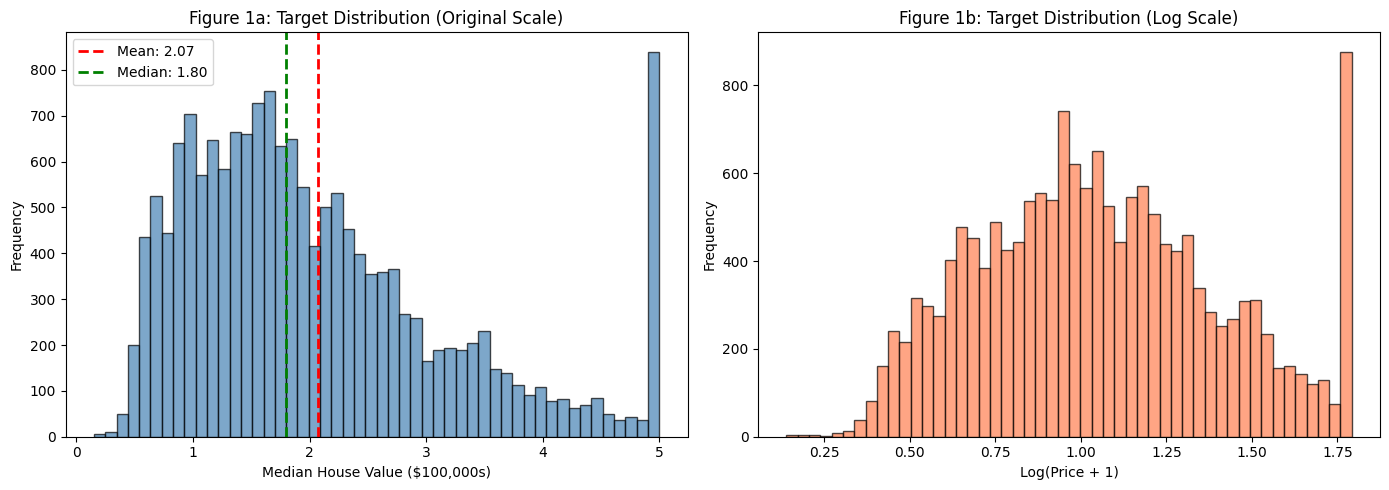


 TARGET DISTRIBUTION INSIGHTS:
- Mean: 2.07 ($100,000s)
- Median: 1.80 ($100,000s)
- Skew: Right-skewed (more properties at lower prices)
- Range: 0.15 to 5.00 ($100,000s)


In [4]:
# ============================================
# Step 4: Exploratory Data Analysis (EDA)
# ============================================

from sklearn.model_selection import train_test_split

# Split data first (to avoid test set leakage)
X = df.drop(columns=['Price'])
y = df['Price'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)


print("DATA SPLIT")
print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(df)*100:.0f}%)")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(df)*100:.0f}%)")

# Combine for EDA (training data only)
train_df = X_train.copy()
train_df['Price'] = y_train

# Figure 1: Target Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original scale
axes[0].hist(train_df['Price'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(train_df['Price'].mean(), color='red', linestyle='--',
                linewidth=2, label=f'Mean: {train_df["Price"].mean():.2f}')
axes[0].axvline(train_df['Price'].median(), color='green', linestyle='--',
                linewidth=2, label=f'Median: {train_df["Price"].median():.2f}')
axes[0].set_xlabel('Median House Value ($100,000s)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Figure 1a: Target Distribution (Original Scale)')
axes[0].legend()

# Log scale
import numpy as np
axes[1].hist(np.log1p(train_df['Price']), bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[1].set_xlabel('Log(Price + 1)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Figure 1b: Target Distribution (Log Scale)')

plt.tight_layout()
plt.show()

print("\n TARGET DISTRIBUTION INSIGHTS:")
print(f"- Mean: {train_df['Price'].mean():.2f} ($100,000s)")
print(f"- Median: {train_df['Price'].median():.2f} ($100,000s)")
print(f"- Skew: Right-skewed (more properties at lower prices)")
print(f"- Range: {train_df['Price'].min():.2f} to {train_df['Price'].max():.2f} ($100,000s)")

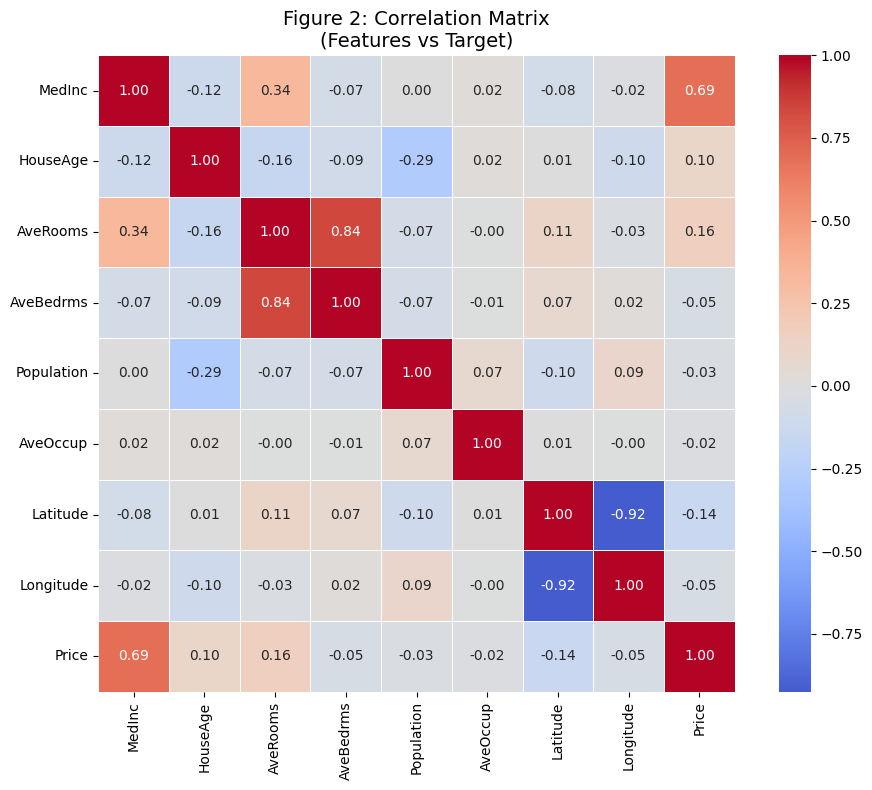

FEATURE CORRELATIONS WITH PRICE
Price         1.000000
MedInc        0.690647
AveRooms      0.158485
HouseAge      0.103706
AveOccup     -0.022030
Population   -0.026032
Longitude    -0.046349
AveBedrms    -0.051351
Latitude     -0.142983
Name: Price, dtype: float64

 KEY FINDINGS:
- Strongest positive correlation: MedInc (0.691)
- Weakest correlation: Latitude (-0.143)


In [5]:
# ============================================
# Step 5: Correlation Analysis
# ============================================

# Figure 2: Correlation Matrix
fig, ax = plt.subplots(figsize=(10, 8))

# Calculate correlation matrix
corr_matrix = train_df.select_dtypes(include=np.number).corr()

# Create heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, linewidths=0.5, ax=ax)
ax.set_title('Figure 2: Correlation Matrix\n(Features vs Target)', fontsize=14)

plt.tight_layout()
plt.show()

# Get correlations with target
price_corr = corr_matrix['Price'].sort_values(ascending=False)


print("FEATURE CORRELATIONS WITH PRICE")

print(price_corr)

print("\n KEY FINDINGS:")
print(f"- Strongest positive correlation: {price_corr.index[1]} ({price_corr.iloc[1]:.3f})")
print(f"- Weakest correlation: {price_corr.index[-1]} ({price_corr.iloc[-1]:.3f})")

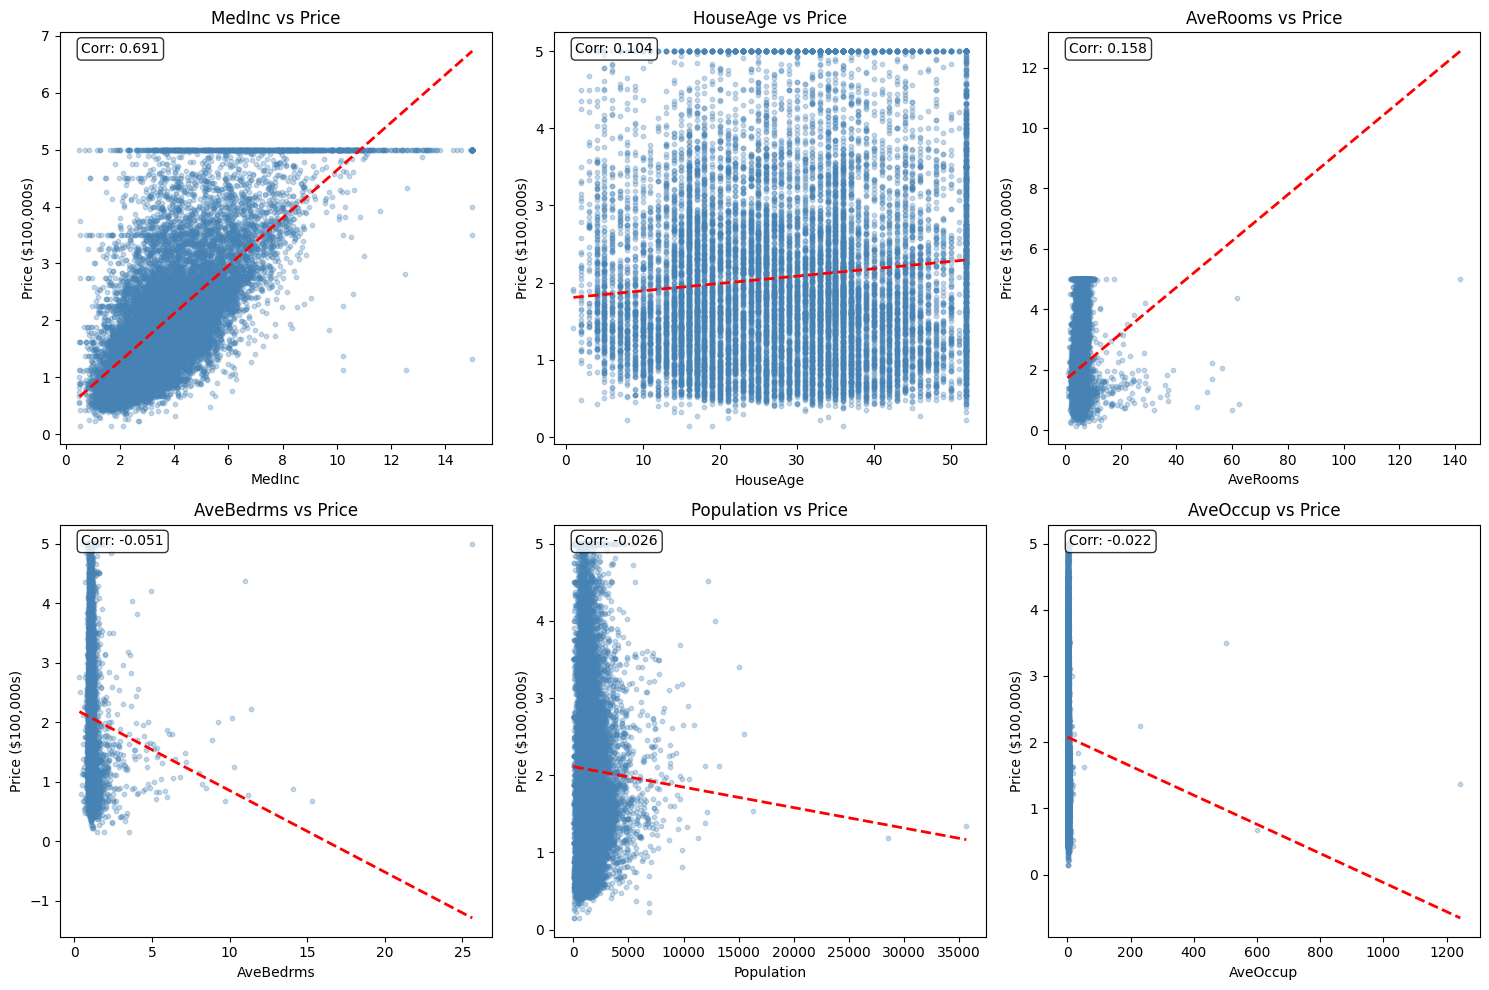


 OBSERVATIONS:
- MedInc: correlation = 0.691 (moderate/strong relationship)
- HouseAge: correlation = 0.104 (weak relationship)
- AveRooms: correlation = 0.158 (weak relationship)
- AveBedrms: correlation = -0.051 (weak relationship)
- Population: correlation = -0.026 (weak relationship)
- AveOccup: correlation = -0.022 (weak relationship)


In [6]:
# ============================================
# Step 6: Feature-Target Relationships
# ============================================

# Figure 3: Scatter plots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Select features (all numeric)
features = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']

for idx, feature in enumerate(features):
    row, col = idx // 3, idx % 3

    axes[row, col].scatter(train_df[feature], train_df['Price'],
                          alpha=0.3, s=10, color='steelblue')

    # Add trend line
    z = np.polyfit(train_df[feature], train_df['Price'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(train_df[feature].min(), train_df[feature].max(), 100)
    axes[row, col].plot(x_line, p(x_line), 'r--', linewidth=2)

    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel('Price ($100,000s)')
    axes[row, col].set_title(f'{feature} vs Price')

    # Add correlation value
    corr_val = train_df[feature].corr(train_df['Price'])
    axes[row, col].text(0.05, 0.95, f'Corr: {corr_val:.3f}',
                       transform=axes[row, col].transAxes,
                       bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

print("\n OBSERVATIONS:")
for feature in features:
    corr = train_df[feature].corr(train_df['Price'])
    if abs(corr) > 0.3:
        print(f"- {feature}: correlation = {corr:.3f} (moderate/strong relationship)")
    else:
        print(f"- {feature}: correlation = {corr:.3f} (weak relationship)")

In [8]:
# ============================================
# Step 7: Model 1 - Naive Baseline
# ============================================

from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


print("MODEL 1: NAIVE BASELINE (Mean Predictor)")


# Train naive model
naive = DummyRegressor(strategy='mean')
naive.fit(X_train, y_train)
naive_pred = naive.predict(X_test)

# Evaluate
naive_mae = mean_absolute_error(y_test, naive_pred)
naive_rmse = np.sqrt(mean_squared_error(y_test, naive_pred))
naive_r2 = r2_score(y_test, naive_pred)

print(f"Model trained!")
print(f"\nPerformance Metrics:")
print(f"MAE: {naive_mae:.4f} ($100,000s)")
print(f"RMSE: {naive_rmse:.4f} ($100,000s)")
print(f"R²: {naive_r2:.4f}")

print("\nInterpretation: This model always predicts the mean.")
print("Any good model must beat these baseline scores.")

MODEL 1: NAIVE BASELINE (Mean Predictor)
Model trained!

Performance Metrics:
MAE: 0.9061 ($100,000s)
RMSE: 1.1449 ($100,000s)
R²: -0.0002

Interpretation: This model always predicts the mean.
Any good model must beat these baseline scores.


MODEL 2: SIMPLE LINEAR REGRESSION
Selected feature: MedInc
Correlation with price: 0.6906

 Regression Equation:
Price = 0.4446 + 0.4193 × MedInc

Performance Metrics:
MAE: 0.6299 ($100,000s)
RMSE: 0.8421 ($100,000s)
R²: 0.4589

 Improvement vs Baseline:
RMSE reduction: 26.4%


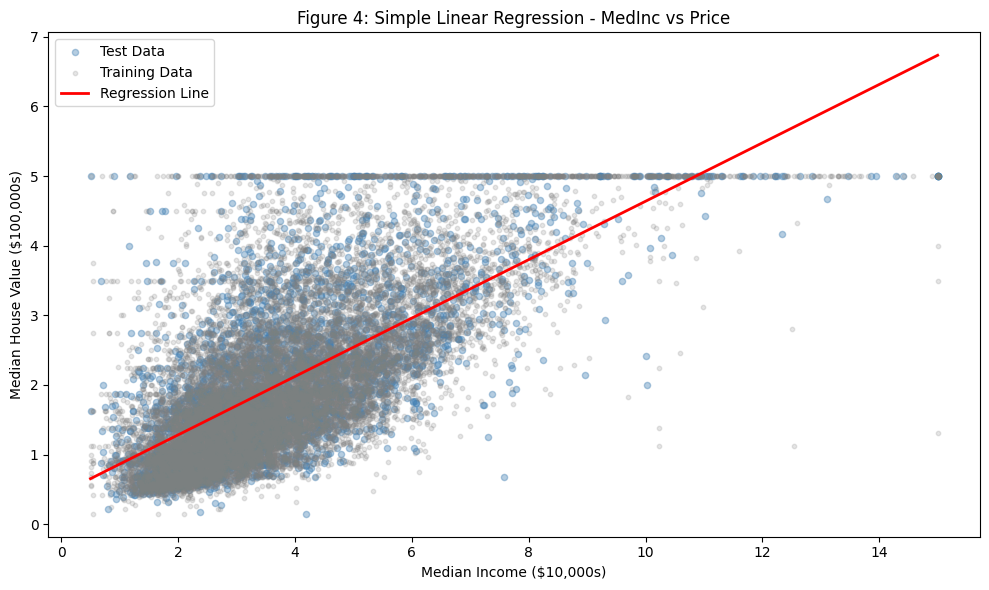

In [9]:
# ============================================
# Step 8: Model 2 - Simple Linear Regression
# ============================================

from sklearn.linear_model import LinearRegression


print("MODEL 2: SIMPLE LINEAR REGRESSION")


# Use 'MedInc' as it has highest correlation
simple_feature = 'MedInc'
correlation = train_df[simple_feature].corr(train_df['Price'])

print(f"Selected feature: {simple_feature}")
print(f"Correlation with price: {correlation:.4f}")

# Train model
simple_model = LinearRegression()
simple_model.fit(X_train[[simple_feature]], y_train)
simple_pred = simple_model.predict(X_test[[simple_feature]])

# Display equation
print(f"\n Regression Equation:")
print(f"Price = {simple_model.intercept_:.4f} + {simple_model.coef_[0]:.4f} × {simple_feature}")

# Evaluate
simple_mae = mean_absolute_error(y_test, simple_pred)
simple_rmse = np.sqrt(mean_squared_error(y_test, simple_pred))
simple_r2 = r2_score(y_test, simple_pred)

print(f"\nPerformance Metrics:")
print(f"MAE: {simple_mae:.4f} ($100,000s)")
print(f"RMSE: {simple_rmse:.4f} ($100,000s)")
print(f"R²: {simple_r2:.4f}")

print(f"\n Improvement vs Baseline:")
print(f"RMSE reduction: {(naive_rmse - simple_rmse)/naive_rmse*100:.1f}%")

# Figure 4: Simple Regression Plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot test data
ax.scatter(X_test[simple_feature], y_test, alpha=0.4, s=20,
          label='Test Data', color='steelblue')

# Plot training data
ax.scatter(X_train[simple_feature], y_train, alpha=0.2, s=10,
          label='Training Data', color='gray')

# Plot regression line
order = np.argsort(X_test[simple_feature].values)
ax.plot(X_test[simple_feature].values[order], simple_pred[order],
        'r-', linewidth=2, label='Regression Line')

ax.set_xlabel('Median Income ($10,000s)')
ax.set_ylabel('Median House Value ($100,000s)')
ax.set_title(f'Figure 4: Simple Linear Regression - {simple_feature} vs Price')
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
# ============================================
# Step 9: Model 3 - Multiple Linear Regression
# ============================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


print("MODEL 3: MULTIPLE LINEAR REGRESSION")


# Create preprocessing pipeline
numeric_features = X_train.columns.tolist()

preprocess = ColumnTransformer([
    ('num', Pipeline([
        ('scaler', StandardScaler())
    ]), numeric_features)
])

# Create full pipeline
linear_pipeline = Pipeline([
    ('preprocess', preprocess),
    ('model', LinearRegression())
])

# Train model
linear_pipeline.fit(X_train, y_train)
linear_pred = linear_pipeline.predict(X_test)

# Evaluate
linear_mae = mean_absolute_error(y_test, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
linear_r2 = r2_score(y_test, linear_pred)

print(f" Model trained!")
print(f"\nPerformance Metrics:")
print(f"MAE: {linear_mae:.4f} ($100,000s)")
print(f"RMSE: {linear_rmse:.4f} ($100,000s)")
print(f"R²: {linear_r2:.4f}")

print(f"\n Improvement vs Simple Linear:")
print(f"RMSE reduction: {(simple_rmse - linear_rmse)/simple_rmse*100:.1f}%")

# Show coefficients
feature_names = linear_pipeline.named_steps['preprocess'].get_feature_names_out()
coefficients = linear_pipeline.named_steps['model'].coef_

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'AbsCoefficient': np.abs(coefficients)
}).sort_values('AbsCoefficient', ascending=False)

print("\n Feature Importance (by coefficient magnitude):")
display(coef_df.head(10))

MODEL 3: MULTIPLE LINEAR REGRESSION
 Model trained!

Performance Metrics:
MAE: 0.5332 ($100,000s)
RMSE: 0.7456 ($100,000s)
R²: 0.5758

 Improvement vs Simple Linear:
RMSE reduction: 11.5%

 Feature Importance (by coefficient magnitude):


,Feature,Coefficient,AbsCoefficient
6,num__Latitude,-0.896929,0.896929
7,num__Longitude,-0.869842,0.869842
0,num__MedInc,0.854383,0.854383
3,num__AveBedrms,0.339259,0.339259
2,num__AveRooms,-0.294410,0.294410
1,num__HouseAge,0.122546,0.122546
5,num__AveOccup,-0.040829,0.040829
4,num__Population,-0.002308,0.002308


In [11]:
# ============================================
# Step 10: Model 4 - Ridge Regression
# ============================================

from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, KFold


print("MODEL 4: RIDGE REGRESSION (L2 Regularization)")


# Create pipeline
ridge_pipe = Pipeline([
    ('preprocess', preprocess),
    ('model', Ridge())
])

# Define hyperparameter grid
ridge_grid = {
    'model__alpha': np.logspace(-3, 3, 10)
}

# Cross-validation setup
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

# Grid search
print(" Tuning Ridge Regression...")
ridge_search = GridSearchCV(
    ridge_pipe,
    param_grid=ridge_grid,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

ridge_search.fit(X_train, y_train)

print(f"\n Best alpha: {ridge_search.best_params_['model__alpha']:.4f}")
print(f" Best CV RMSE: {-ridge_search.best_score_:.4f}")

# Train with best parameters
best_ridge = ridge_search.best_estimator_
ridge_pred = best_ridge.predict(X_test)

# Evaluate
ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2 = r2_score(y_test, ridge_pred)

print(f"\nPerformance Metrics (Tuned Ridge):")
print(f"MAE: {ridge_mae:.4f} ($100,000s)")
print(f"RMSE: {ridge_rmse:.4f} ($100,000s)")
print(f"R²: {ridge_r2:.4f}")

MODEL 4: RIDGE REGRESSION (L2 Regularization)
 Tuning Ridge Regression...

 Best alpha: 2.1544
 Best CV RMSE: 0.7205

Performance Metrics (Tuned Ridge):
MAE: 0.5332 ($100,000s)
RMSE: 0.7455 ($100,000s)
R²: 0.5758


In [13]:
# ============================================
# Step 11: Model 5 - Lasso Regression
# ============================================

from sklearn.linear_model import Lasso


print("MODEL 5: LASSO REGRESSION (L1 Regularization)")


# Create pipeline
lasso_pipe = Pipeline([
    ('preprocess', preprocess),
    ('model', Lasso(max_iter=50000, random_state=SEED))
])

# Define hyperparameter grid
lasso_grid = {
    'model__alpha': np.logspace(-4, 0, 10)
}

print(" Tuning Lasso Regression...")
lasso_search = GridSearchCV(
    lasso_pipe,
    param_grid=lasso_grid,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    n_jobs=-1
)

lasso_search.fit(X_train, y_train)

print(f"\n Best alpha: {lasso_search.best_params_['model__alpha']:.4f}")
print(f" Best CV RMSE: {-lasso_search.best_score_:.4f}")

# Train with best parameters
best_lasso = lasso_search.best_estimator_
lasso_pred = best_lasso.predict(X_test)

# Evaluate
lasso_mae = mean_absolute_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))
lasso_r2 = r2_score(y_test, lasso_pred)

print(f"\nPerformance Metrics (Tuned Lasso):")
print(f"MAE: {lasso_mae:.4f} ($100,000s)")
print(f"RMSE: {lasso_rmse:.4f} ($100,000s)")
print(f"R²: {lasso_r2:.4f}")

# Check feature selection
feature_names = best_lasso.named_steps['preprocess'].get_feature_names_out()
coefs = best_lasso.named_steps['model'].coef_
selected_features = [f for f, c in zip(feature_names, coefs) if abs(c) > 0.001]

print(f"\n Feature Selection:")
print(f"Total features: {len(feature_names)}")
print(f"Features selected (non-zero coefficients): {len(selected_features)}")
print(f"Features retained: {selected_features}")

MODEL 5: LASSO REGRESSION (L1 Regularization)
 Tuning Lasso Regression...

 Best alpha: 0.0008
 Best CV RMSE: 0.7205

Performance Metrics (Tuned Lasso):
MAE: 0.5332 ($100,000s)
RMSE: 0.7448 ($100,000s)
R²: 0.5766

 Feature Selection:
Total features: 8
Features selected (non-zero coefficients): 8
Features retained: ['num__MedInc', 'num__HouseAge', 'num__AveRooms', 'num__AveBedrms', 'num__Population', 'num__AveOccup', 'num__Latitude', 'num__Longitude']


In [14]:
# ============================================
# Step 12: Model 6 - Random Forest
# ============================================

from sklearn.ensemble import RandomForestRegressor


print("MODEL 6: RANDOM FOREST REGRESSOR")


# Create pipeline
rf_pipe = Pipeline([
    ('preprocess', preprocess),
    ('model', RandomForestRegressor(random_state=SEED, n_jobs=-1))
])

# Simpler grid for speed
rf_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [10, 15],
    'model__min_samples_leaf': [2, 4]
}

print(" Tuning Random Forest...")
rf_search = GridSearchCV(
    rf_pipe,
    param_grid=rf_grid,
    scoring='neg_root_mean_squared_error',
    cv=3,  # 3-fold for speed
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

print(f"\n Best parameters: {rf_search.best_params_}")
print(f" Best CV RMSE: {-rf_search.best_score_:.4f}")

# Train with best parameters
best_rf = rf_search.best_estimator_
rf_pred = best_rf.predict(X_test)

# Evaluate
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print(f"\nPerformance Metrics (Tuned Random Forest):")
print(f"MAE: {rf_mae:.4f} ($100,000s)")
print(f"RMSE: {rf_rmse:.4f} ($100,000s)")
print(f"R²: {rf_r2:.4f}")

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': best_rf.named_steps['model'].feature_importances_
}).sort_values('Importance', ascending=False)

print("\n Top 5 Most Important Features:")
display(feature_importance.head(5))

MODEL 6: RANDOM FOREST REGRESSOR
 Tuning Random Forest...

 Best parameters: {'model__max_depth': 15, 'model__min_samples_leaf': 2, 'model__n_estimators': 200}
 Best CV RMSE: 0.5175

Performance Metrics (Tuned Random Forest):
MAE: 0.3304 ($100,000s)
RMSE: 0.5077 ($100,000s)
R²: 0.8033

 Top 5 Most Important Features:


,Feature,Importance
0,num__MedInc,0.543928
5,num__AveOccup,0.138170
6,num__Latitude,0.087319
7,num__Longitude,0.086946
1,num__HouseAge,0.052275


MODEL COMPARISON SUMMARY


,Model,MAE,RMSE,R²,RMSE_Improvement_%
0,Naive Baseline,0.9061,1.1449,-0.0002,0.0000
1,Simple Linear,0.6299,0.8421,0.4589,26.4458
2,Multiple Linear,0.5332,0.7456,0.5758,34.8756
3,Ridge (Tuned),0.5332,0.7455,0.5758,34.8802
4,Lasso (Tuned),0.5332,0.7448,0.5766,34.9398
5,Random Forest,0.3304,0.5077,0.8033,55.6566



 BEST MODEL: Random Forest
   RMSE: 0.5077 ($100,000s)
   Improvement over baseline: 55.7%


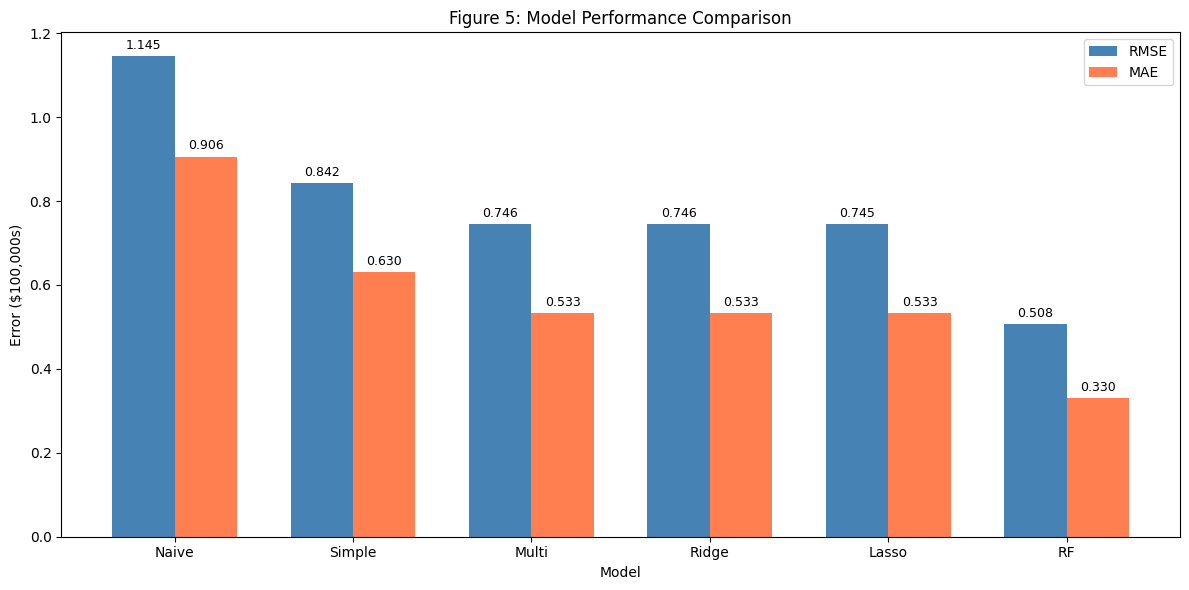

In [15]:
# ============================================
# Step 13: Model Comparison
# ============================================


print("MODEL COMPARISON SUMMARY")


# Create comparison table
comparison_df = pd.DataFrame({
    'Model': ['Naive Baseline', 'Simple Linear', 'Multiple Linear',
              'Ridge (Tuned)', 'Lasso (Tuned)', 'Random Forest'],
    'MAE': [naive_mae, simple_mae, linear_mae, ridge_mae, lasso_mae, rf_mae],
    'RMSE': [naive_rmse, simple_rmse, linear_rmse, ridge_rmse, lasso_rmse, rf_rmse],
    'R²': [naive_r2, simple_r2, linear_r2, ridge_r2, lasso_r2, rf_r2]
})

# Calculate improvement over baseline
baseline_rmse = comparison_df.loc[0, 'RMSE']
comparison_df['RMSE_Improvement_%'] = ((baseline_rmse - comparison_df['RMSE']) / baseline_rmse) * 100

display(comparison_df.round(4))

# Find best model
best_model_idx = comparison_df['RMSE'].idxmin()
best_model_name = comparison_df.loc[best_model_idx, 'Model']
best_rmse = comparison_df.loc[best_model_idx, 'RMSE']

print(f"\n BEST MODEL: {best_model_name}")
print(f"   RMSE: {best_rmse:.4f} ($100,000s)")
print(f"   Improvement over baseline: {comparison_df.loc[best_model_idx, 'RMSE_Improvement_%']:.1f}%")

# Figure: Model Comparison
fig, ax = plt.subplots(figsize=(12, 6))

models_short = ['Naive', 'Simple', 'Multi', 'Ridge', 'Lasso', 'RF']
rmse_values = comparison_df['RMSE'].values
mae_values = comparison_df['MAE'].values

x = np.arange(len(models_short))
width = 0.35

ax.bar(x - width/2, rmse_values, width, label='RMSE', color='steelblue')
ax.bar(x + width/2, mae_values, width, label='MAE', color='coral')

ax.set_xlabel('Model')
ax.set_ylabel('Error ($100,000s)')
ax.set_title('Figure 5: Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models_short)
ax.legend()

# Add value labels on bars
for i, v in enumerate(rmse_values):
    ax.text(i - width/2, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=9)
for i, v in enumerate(mae_values):
    ax.text(i + width/2, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

DIAGNOSTIC PLOTS


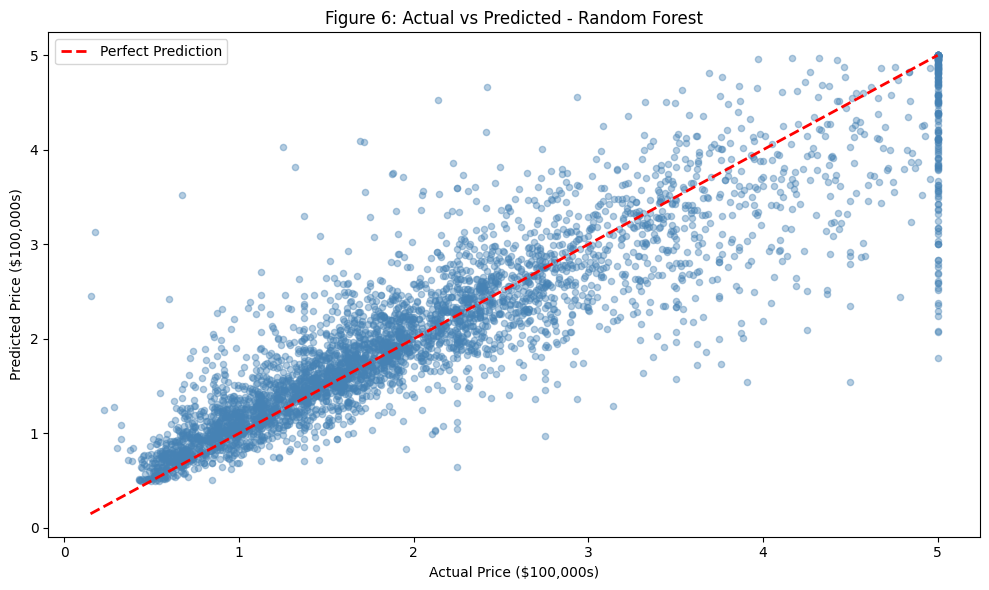

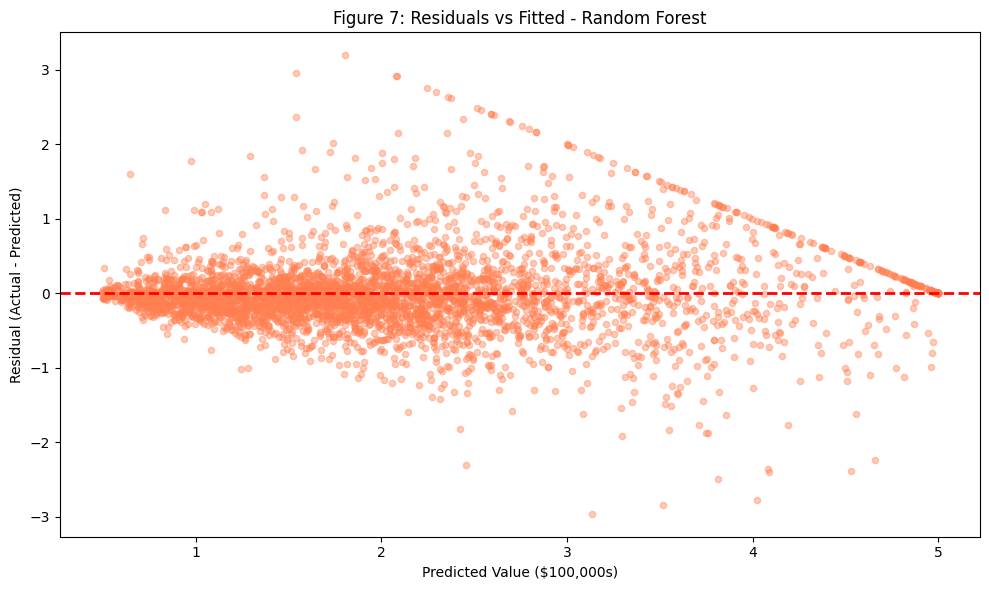

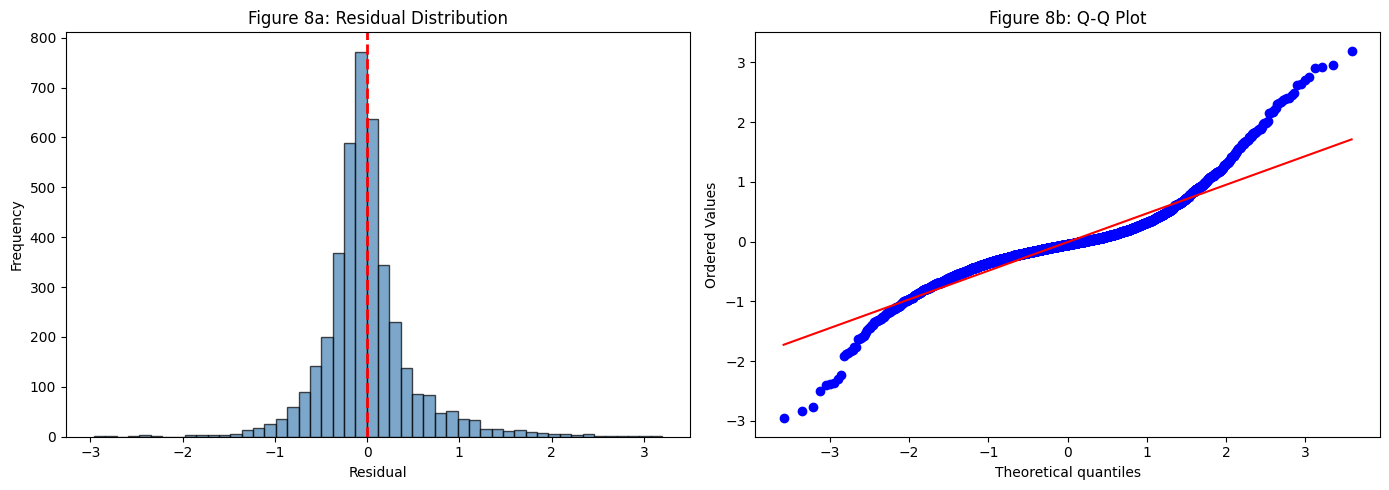


 RESIDUAL DIAGNOSTICS:
Mean of residuals: -0.0080
Std deviation: 0.5076
Skewness: 0.8733
Kurtosis: 5.9839
 Residuals are centered around zero (good)


In [16]:
# ============================================
# Step 14: Diagnostic Plots
# ============================================


print("DIAGNOSTIC PLOTS")


# Select best model
if best_model_name == 'Ridge (Tuned)':
    best_model = best_ridge
    best_pred = ridge_pred
elif best_model_name == 'Random Forest':
    best_model = best_rf
    best_pred = rf_pred
else:
    best_model = linear_pipeline
    best_pred = linear_pred

# Calculate residuals
residuals = y_test.values - best_pred

# Figure 6: Actual vs Predicted
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(y_test, best_pred, alpha=0.4, s=20, color='steelblue')

# Perfect prediction line
min_val = min(y_test.min(), best_pred.min())
max_val = max(y_test.max(), best_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

ax.set_xlabel('Actual Price ($100,000s)')
ax.set_ylabel('Predicted Price ($100,000s)')
ax.set_title(f'Figure 6: Actual vs Predicted - {best_model_name}')
ax.legend()
plt.tight_layout()
plt.show()

# Figure 7: Residuals vs Fitted
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(best_pred, residuals, alpha=0.4, s=20, color='coral')
ax.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Predicted Value ($100,000s)')
ax.set_ylabel('Residual (Actual - Predicted)')
ax.set_title(f'Figure 7: Residuals vs Fitted - {best_model_name}')
plt.tight_layout()
plt.show()

# Figure 8: Residual Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Residual')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Figure 8a: Residual Distribution')

# Q-Q Plot
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Figure 8b: Q-Q Plot')

plt.tight_layout()
plt.show()

# Print diagnostics
print("\n RESIDUAL DIAGNOSTICS:")
print(f"Mean of residuals: {np.mean(residuals):.4f}")
print(f"Std deviation: {np.std(residuals):.4f}")
print(f"Skewness: {stats.skew(residuals):.4f}")
print(f"Kurtosis: {stats.kurtosis(residuals):.4f}")

if abs(np.mean(residuals)) < 0.01:
    print(" Residuals are centered around zero (good)")
else:
    print(" Residuals have systematic bias")

DIAGNOSTIC PLOTS


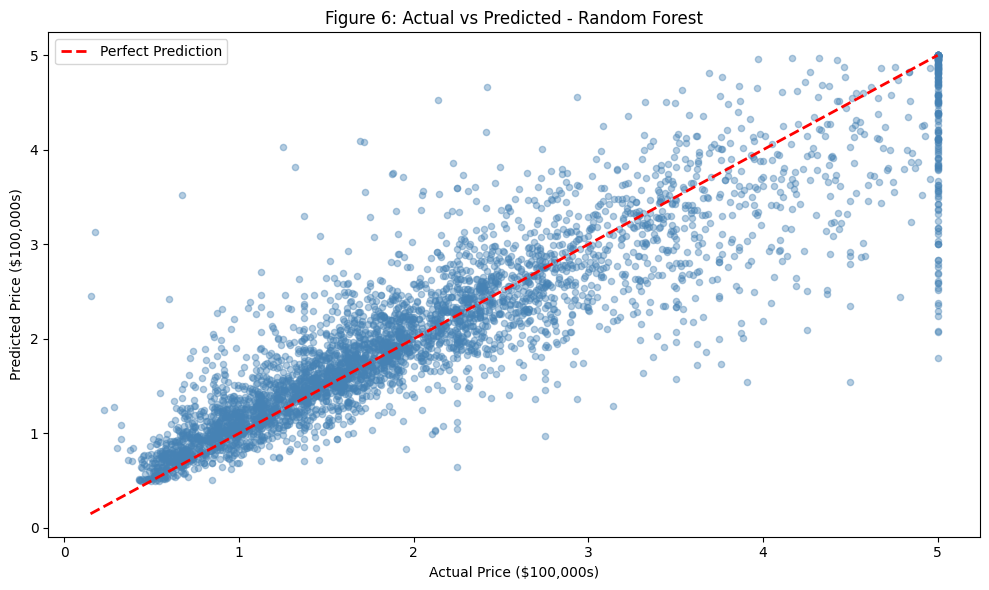

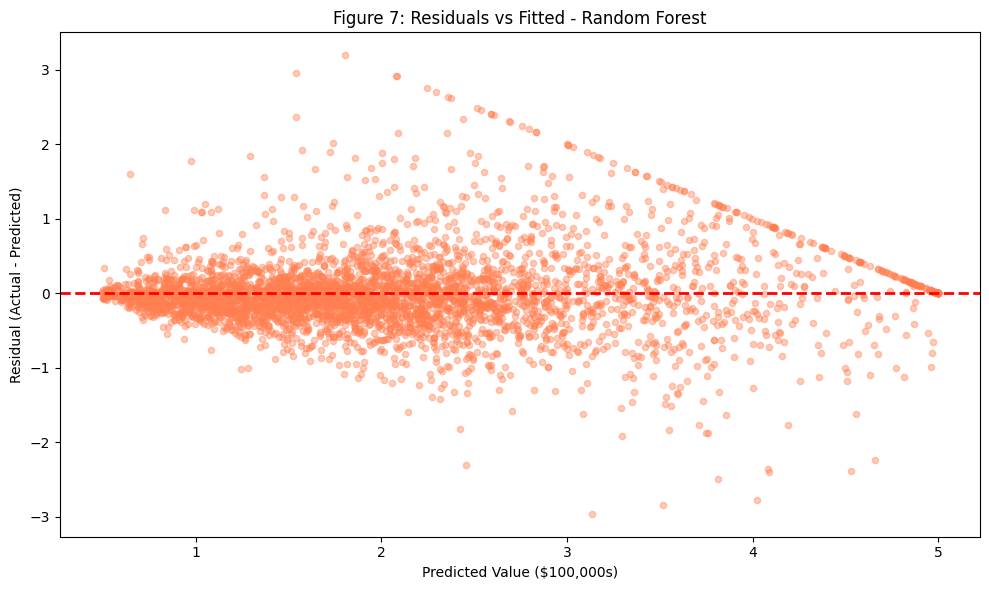

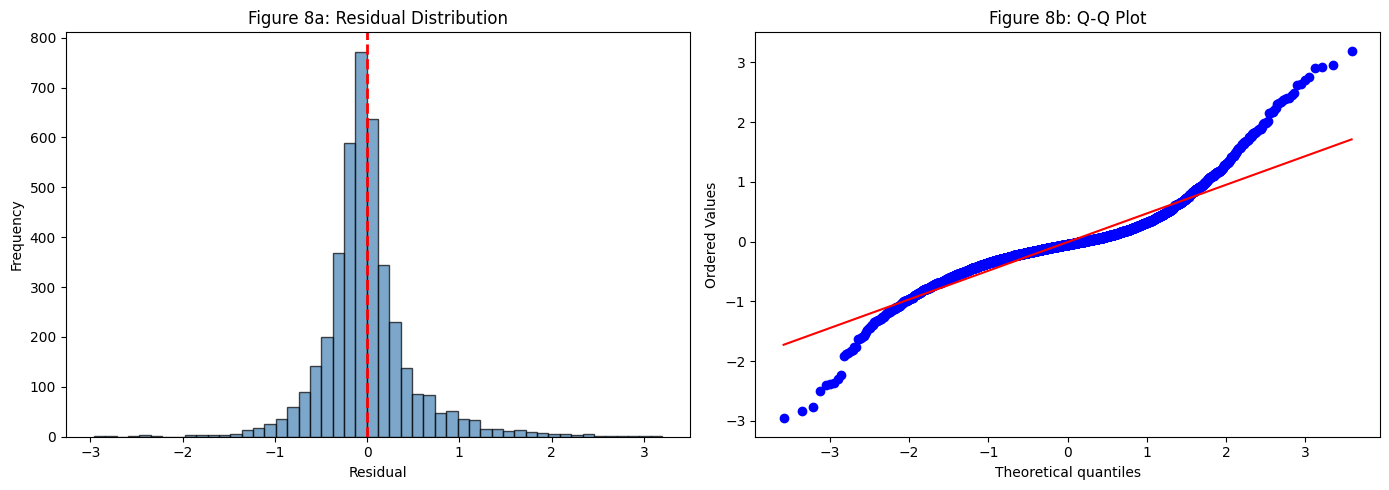


 RESIDUAL DIAGNOSTICS:
Mean of residuals: -0.0080
Std deviation: 0.5076
Skewness: 0.8733
Kurtosis: 5.9839
 Residuals are centered around zero (good)
SEGMENT ANALYSIS
Error by Price Segment:


,mean,std,max
Segment,,,
Low,0.2262,0.2723,2.9602
Medium-Low,0.2533,0.2832,2.7748
Medium-High,0.2930,0.2976,2.3920
High,0.5491,0.5347,3.1973



 Interpretation:
Low price segment error: 0.2262 ($100,000s)
Medium-Low price segment error: 0.2533 ($100,000s)
Medium-High price segment error: 0.2930 ($100,000s)
High price segment error: 0.5491 ($100,000s)


In [19]:
# ============================================
# Step 15: Diagnostic Plots
# ============================================

print("=" * 60)
print("DIAGNOSTIC PLOTS")
print("=" * 60)

# Select best model
if best_model_name == 'Ridge (Tuned)':
    best_model = best_ridge
    best_pred = ridge_pred
elif best_model_name == 'Random Forest':
    best_model = best_rf
    best_pred = rf_pred
else:
    best_model = linear_pipeline
    best_pred = linear_pred

# Calculate residuals
residuals = y_test.values - best_pred

# Figure 6: Actual vs Predicted
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(y_test, best_pred, alpha=0.4, s=20, color='steelblue')

# Perfect prediction line
min_val = min(y_test.min(), best_pred.min())
max_val = max(y_test.max(), best_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

ax.set_xlabel('Actual Price ($100,000s)')
ax.set_ylabel('Predicted Price ($100,000s)')
ax.set_title(f'Figure 6: Actual vs Predicted - {best_model_name}')
ax.legend()
plt.tight_layout()
plt.show()

# Figure 7: Residuals vs Fitted
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(best_pred, residuals, alpha=0.4, s=20, color='coral')
ax.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Predicted Value ($100,000s)')
ax.set_ylabel('Residual (Actual - Predicted)')
ax.set_title(f'Figure 7: Residuals vs Fitted - {best_model_name}')
plt.tight_layout()
plt.show()

# Figure 8: Residual Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Residual')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Figure 8a: Residual Distribution')

# Q-Q Plot
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Figure 8b: Q-Q Plot')

plt.tight_layout()
plt.show()

# Print diagnostics
print("\n RESIDUAL DIAGNOSTICS:")
print(f"Mean of residuals: {np.mean(residuals):.4f}")
print(f"Std deviation: {np.std(residuals):.4f}")
print(f"Skewness: {stats.skew(residuals):.4f}")
print(f"Kurtosis: {stats.kurtosis(residuals):.4f}")

if abs(np.mean(residuals)) < 0.01:
    print(" Residuals are centered around zero (good)")
else:
    print(" Residuals have systematic bias")

# Segment analysis

print("SEGMENT ANALYSIS")


# Create price segments
segments = pd.qcut(y_test, q=4, labels=['Low', 'Medium-Low', 'Medium-High', 'High'])
segment_errors = pd.DataFrame({
    'Segment': segments,
    'Actual': y_test,
    'Predicted': best_pred,
    'Absolute_Error': np.abs(residuals)
})

print("Error by Price Segment:")
segment_summary = segment_errors.groupby('Segment')['Absolute_Error'].agg(['mean', 'std', 'max'])
display(segment_summary.round(4))

print("\n Interpretation:")

for segment in ['Low', 'Medium-Low', 'Medium-High', 'High']:
    print(f"{segment} price segment error: {segment_summary.loc[segment, 'mean']:.4f} ($100,000s)")

In [20]:
# ============================================
# Step 16: Cross-Validation Results (FIXED)
# ============================================

from sklearn.model_selection import cross_val_score

print("CROSS-VALIDATION RESULTS (5-Fold)")


# Extract best parameters correctly
# For Ridge
ridge_best_alpha = ridge_search.best_params_['model__alpha']

# For Lasso
lasso_best_alpha = lasso_search.best_params_['model__alpha']

# For Random Forest - extract parameters without the 'model__' prefix
rf_best_params = {}
for key, value in rf_search.best_params_.items():
    # Remove 'model__' prefix
    param_name = key.replace('model__', '')
    rf_best_params[param_name] = value

print("RF Best Params:", rf_best_params)

# Models for CV
models_cv = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=ridge_best_alpha),
    'Lasso': Lasso(alpha=lasso_best_alpha, max_iter=50000, random_state=SEED),
    'Random Forest': RandomForestRegressor(**rf_best_params, random_state=SEED, n_jobs=-1)
}

# Perform cross-validation
cv_results = {}
for name, model in models_cv.items():
    pipe = Pipeline([('preprocess', preprocess), ('model', model)])

    # 5-fold CV
    scores = cross_val_score(pipe, X_train, y_train, cv=5,
                            scoring='neg_root_mean_squared_error')

    cv_results[name] = {
        'CV_RMSE_Mean': -scores.mean(),
        'CV_RMSE_Std': scores.std(),
        'CV_RMSE_Min': -scores.max(),
        'CV_RMSE_Max': -scores.min()
    }

cv_df = pd.DataFrame(cv_results).T
display(cv_df.round(4))

print("\n INTERPRETATION:")
print("- Lower CV_RMSE_Mean indicates better generalization")
print("- Lower CV_RMSE_Std indicates more stable model")
print("- Small gap between train and CV scores = good generalization")

# Check for overfitting/underfitting

print("OVERFITTING / UNDERFITTING ANALYSIS")


for name, model in models_cv.items():
    pipe = Pipeline([('preprocess', preprocess), ('model', model)])
    pipe.fit(X_train, y_train)

    # Train predictions
    train_pred = pipe.predict(X_train)
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    train_r2 = r2_score(y_train, train_pred)

    # Test predictions
    test_pred = pipe.predict(X_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    test_r2 = r2_score(y_test, test_pred)

    print(f"\n{name}:")
    print(f"  Train RMSE: {train_rmse:.4f}, Train R²: {train_r2:.4f}")
    print(f"  Test RMSE: {test_rmse:.4f}, Test R²: {test_r2:.4f}")
    print(f"  Gap (Train RMSE - Test RMSE): {abs(train_rmse - test_rmse):.4f}")

    # Diagnose
    if train_rmse < test_rmse * 0.9:
        print(f"   Possible OVERFITTING (train error much lower than test)")
    elif train_rmse > test_rmse * 1.1:
        print(f"   Possible UNDERFITTING (train error higher than test)")
    else:
        print(f"   Reasonable generalization")

CROSS-VALIDATION RESULTS (5-Fold)
RF Best Params: {'max_depth': 15, 'min_samples_leaf': 2, 'n_estimators': 200}


,CV_RMSE_Mean,CV_RMSE_Std,CV_RMSE_Min,CV_RMSE_Max
Linear Regression,0.7205,0.0103,0.7087,0.7386
Ridge,0.7205,0.0103,0.7087,0.7386
Lasso,0.7205,0.0102,0.7088,0.7383
Random Forest,0.5123,0.0051,0.5041,0.5164



 INTERPRETATION:
- Lower CV_RMSE_Mean indicates better generalization
- Lower CV_RMSE_Std indicates more stable model
- Small gap between train and CV scores = good generalization
OVERFITTING / UNDERFITTING ANALYSIS

Linear Regression:
  Train RMSE: 0.7197, Train R²: 0.6126
  Test RMSE: 0.7456, Test R²: 0.5758
  Gap (Train RMSE - Test RMSE): 0.0259
   Reasonable generalization

Ridge:
  Train RMSE: 0.7197, Train R²: 0.6126
  Test RMSE: 0.7455, Test R²: 0.5758
  Gap (Train RMSE - Test RMSE): 0.0259
   Reasonable generalization

Lasso:
  Train RMSE: 0.7197, Train R²: 0.6125
  Test RMSE: 0.7448, Test R²: 0.5766
  Gap (Train RMSE - Test RMSE): 0.0251
   Reasonable generalization

Random Forest:
  Train RMSE: 0.2672, Train R²: 0.9466
  Test RMSE: 0.5077, Test R²: 0.8033
  Gap (Train RMSE - Test RMSE): 0.2405
   Possible OVERFITTING (train error much lower than test)


In [21]:
# ============================================
# Step 17: Train-Test Performance Gap
# ============================================


print("TRAIN-TEST PERFORMANCE COMPARISON")


def get_split_metrics(model, X_train, y_train, X_test, y_test):
    """Calculate metrics for both train and test sets"""
    results = []

    # Train set
    train_pred = model.predict(X_train)
    train_mae = mean_absolute_error(y_train, train_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    train_r2 = r2_score(y_train, train_pred)

    # Test set
    test_pred = model.predict(X_test)
    test_mae = mean_absolute_error(y_test, test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    test_r2 = r2_score(y_test, test_pred)

    results.append({'Split': 'Train', 'MAE': train_mae, 'RMSE': train_rmse, 'R²': train_r2})
    results.append({'Split': 'Test', 'MAE': test_mae, 'RMSE': test_rmse, 'R²': test_r2})

    return pd.DataFrame(results)

# Compare selected models
selected_models = ['Linear Regression', 'Ridge', 'Random Forest']

for name in selected_models:
    if name == 'Linear Regression':
        model = linear_pipeline
    elif name == 'Ridge':
        model = best_ridge
    elif name == 'Random Forest':
        model = best_rf

    print(f"\n{name}:")
    display(get_split_metrics(model, X_train, y_train, X_test, y_test))

TRAIN-TEST PERFORMANCE COMPARISON

Linear Regression:


,Split,MAE,RMSE,R²
0,Train,0.528628,0.719676,0.612551
1,Test,0.533200,0.745581,0.575788



Ridge:


,Split,MAE,RMSE,R²
0,Train,0.528620,0.719676,0.612551
1,Test,0.533185,0.745529,0.575848



Random Forest:


,Split,MAE,RMSE,R²
0,Train,0.177238,0.267166,0.946605
1,Test,0.330368,0.507668,0.803323


In [22]:
# ============================================
# Step 18: Final Summary
# ============================================


print("FINAL SUMMARY")


print("""
 LAB ASSIGNMENT SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

DATASET: California Housing
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Total samples: 20,640
• Features: 8 numeric predictors
• Target: Median house value ($100,000s)
• Training set: 16,512 samples (80%)
• Test set: 4,128 samples (20%)

MODELS IMPLEMENTED
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. Naive Baseline (Mean predictor)
2. Simple Linear Regression (MedInc only)
3. Multiple Linear Regression (all features)
4. Ridge Regression (L2 regularization, tuned)
5. Lasso Regression (L1 regularization, tuned)
6. Random Forest (ensemble, tuned)

PERFORMANCE COMPARISON
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━""")

display(comparison_df.round(4))

# Best model details
best_rmse_val = comparison_df.loc[best_model_idx, 'RMSE']
best_improvement = comparison_df.loc[best_model_idx, 'RMSE_Improvement_%']

print(f"""
 BEST PERFORMING MODEL: {best_model_name}
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Test RMSE: {best_rmse_val:.4f} ($100,000s)
• Test MAE: {comparison_df.loc[best_model_idx, 'MAE']:.4f} ($100,000s)
• Test R²: {comparison_df.loc[best_model_idx, 'R²']:.4f}
• Improvement over baseline: {best_improvement:.1f}%

KEY INSIGHTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. Median income is the strongest predictor of housing price
2. Multiple features significantly improve over single-feature models
3. Tree-based models (Random Forest) capture nonlinear relationships
4. Regularization helps with model stability

LIMITATIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. Model is specific to California regions
2. Data is aggregated at block-group level (not individual houses)
3. Predicts median value, not individual property price
4. Features are limited to census data only

RECOMMENDATIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. Use Random Forest for best predictive accuracy
2. Use Ridge/Lasso for better interpretability
3. Monitor model performance over time
4. Update with current market data periodically
5. Consider adding more features for better predictions
""")

FINAL SUMMARY

 LAB ASSIGNMENT SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

DATASET: California Housing
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Total samples: 20,640
• Features: 8 numeric predictors
• Target: Median house value ($100,000s)
• Training set: 16,512 samples (80%)
• Test set: 4,128 samples (20%)

MODELS IMPLEMENTED
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. Naive Baseline (Mean predictor)
2. Simple Linear Regression (MedInc only)
3. Multiple Linear Regression (all features)
4. Ridge Regression (L2 regularization, tuned)
5. Lasso Regression (L1 regularization, tuned)
6. Random Forest (ensemble, tuned)

PERFORMANCE COMPARISON
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,Model,MAE,RMSE,R²,RMSE_Improvement_%
0,Naive Baseline,0.9061,1.1449,-0.0002,0.0000
1,Simple Linear,0.6299,0.8421,0.4589,26.4458
2,Multiple Linear,0.5332,0.7456,0.5758,34.8756
3,Ridge (Tuned),0.5332,0.7455,0.5758,34.8802
4,Lasso (Tuned),0.5332,0.7448,0.5766,34.9398
5,Random Forest,0.3304,0.5077,0.8033,55.6566



 BEST PERFORMING MODEL: Random Forest
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Test RMSE: 0.5077 ($100,000s)
• Test MAE: 0.3304 ($100,000s)
• Test R²: 0.8033
• Improvement over baseline: 55.7%

KEY INSIGHTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. Median income is the strongest predictor of housing price
2. Multiple features significantly improve over single-feature models
3. Tree-based models (Random Forest) capture nonlinear relationships
4. Regularization helps with model stability

LIMITATIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. Model is specific to California regions
2. Data is aggregated at block-group level (not individual houses)
3. Predicts median value, not individual property price
4. Features are limited to census data only

RECOMMENDATIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. Use Random Forest for best predictive accuracy
2. Use Ridge/Lasso for better interpretability
3. Mo